In [1]:
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")
print(df.head(5))

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [2]:
''' Ex No 1 '''
#Perform Principal Component Analysis (PCA) to reduce dimensionality and analyze variance.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df[["age", "bmi", "HbA1c_level", "blood_glucose_level"]]
y = df['diabetes']

#scaler for PCA
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [3]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)
print("After Dimensionality Reduction through PCA:")
print(X_pca)
print("\nVariance Analyze:")
print(pca.explained_variance_ratio_)


After Dimensionality Reduction through PCA:
[[ 1.22801131  0.16624328 -0.68017771  1.40560372]
 [ 0.13948388 -0.40350706 -1.72676751  0.40365886]
 [-0.11684865  0.59964361  0.24596566 -0.46099779]
 ...
 [ 0.91378046 -0.07623064  0.17055023  0.69431848]
 [-0.67381688 -1.62874297  0.31342255 -1.35080378]
 [-0.11317633 -0.00363164 -1.53866386  1.00520654]]

Variance Analyze:
[0.36585896 0.2604204  0.20826841 0.16545224]


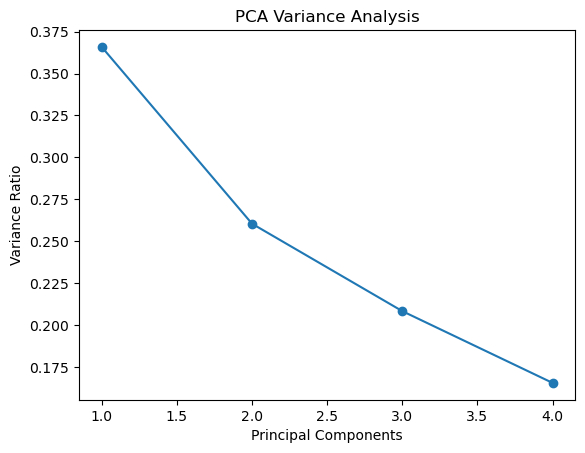

In [4]:
plt.plot(range(1, 5), pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.title("PCA Variance Analysis")
plt.show()

In [5]:
'''Ex No 2'''
#2. Apply Linear Discriminant Analysis (LDA) to classify patients as diabetic (1) or nondiabetic (0) using features: Age, BMI, HbA1c, Glucose

X = df[["age", "bmi", "HbA1c_level", "blood_glucose_level"]]
y = df['diabetes']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [6]:
#apply LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda  = LinearDiscriminantAnalysis()

lda.fit(X_train_scaled, y_train)
y_pred = lda.predict(X_test_scaled)

print(y_pred)

[0 0 0 ... 0 0 0]


In [7]:
from sklearn.metrics import accuracy_score,classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.95595
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.88      0.56      0.68      1708

    accuracy                           0.96     20000
   macro avg       0.92      0.78      0.83     20000
weighted avg       0.95      0.96      0.95     20000



In [8]:
X_lda = lda.transform(X_train_scaled)
print(X_lda.shape)  # (n_samples, 1)

(80000, 1)


In [12]:
new_data = [[50, 28.5, 7.2, 180]]
new_data_scaled = scaler.transform(new_data)
print("LDA Prediction:", lda.predict(new_data_scaled))

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


LDA Prediction: [0]


In [9]:
'''Ex No 3 '''
# 3. Using the Diabetes Prediction Dataset, design and implement Multi-Layer Perceptron (MLP) to classify whether a patient is diabetic or non-diabetic based on features such as: Age, BMI, HbA1c level, Blood Glucose level

X = df[["age", "bmi", "HbA1c_level", "blood_glucose_level"]]
y = df['diabetes']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [10]:
from sklearn.neural_network import MLPClassifier
# MLP Architecture:
# Input layer: 4 neurons (age, bmi, HbA1c, glucose)
# Hidden layers: 8 neurons and 4 neurons with ReLU activation
# Output layer: 1 neuron (binary classification using sigmoid internally)
mlp = MLPClassifier(
    hidden_layer_sizes=(8, 4),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(8, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [11]:
y_pred = mlp.predict(X_test_scaled)

from sklearn.metrics import accuracy_score,classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9709
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.97      0.68      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.97      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



In [14]:
new_data_scaled = scaler.transform(new_data)
print("MLP Prediction:", mlp.predict(new_data_scaled))

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


MLP Prediction: [1]
